   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 25.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 94.0/94.0 kB 5.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 66.8/66.8 kB 4.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 49.9/49.9 MB 19.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.5/1.5 MB 28.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.5/5.5 MB 42.0 MB/s eta 0:00:00


Saving food detect.v13-weak_classes_improved.yolov8.zip to food detect.v13-weak_classes_improved.yolov8.zip
Dataset ready at: food detect.v13-weak_classes_improved.yolov8
Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.
Ultralytics 8.4.14 🚀 Python-3.12.12 torch-2.9.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=4, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=food detect.v13-weak_classes_improved.yolov8/data.yaml, degrees=0.0, deterministic=True, device=0, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=

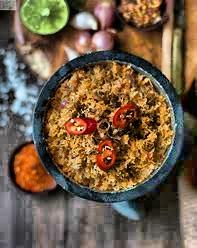

In [1]:
# Step 0: Install packages
!pip install ultralytics roboflow --quiet

# Step 1: Upload your dataset ZIP
from google.colab import files
uploaded = files.upload()  # choose your ZIP file

# Step 2: Unzip the dataset
import zipfile
import os
for fn in uploaded.keys():
    with zipfile.ZipFile(fn, 'r') as zip_ref:
        zip_ref.extractall(fn.replace(".zip",""))

dataset_path = fn.replace(".zip","")
print("Dataset ready at:", dataset_path)

# Step 3: Train a small YOLOv8 model quickly
from ultralytics import YOLO

# Use yolov8n.pt (nano) for very fast training
model = YOLO("yolov8s.pt")

# Quick training settings for testing
model.train(
    data=f"{dataset_path}/data.yaml",  # path to data.yaml
    epochs=40,                          # small number of epochs for fast start
    imgsz=640,                         # smaller images to speed up
    batch=4,                            # smaller batch for Colab free
    project="meal_plate_test",          # save results here
    name="quick_train",
    exist_ok=True,
    device=0
)

# Step 4: Test on one example image
example_image = os.path.join(dataset_path, "valid/images", os.listdir(os.path.join(dataset_path, "valid/images"))[0])
results = model.predict(example_image)
results[0].show()  # show the first (and only) result



Testing on: man6_PNG.rf.2d7fb35d69a974c0d8bf074657009132.jpg

image 1/1 /content/food detect.v13-weak_classes_improved.yolov8/valid/images/man6_PNG.rf.2d7fb35d69a974c0d8bf074657009132.jpg: 640x608 1 Mango curry, 71.9ms
Speed: 3.5ms preprocess, 71.9ms inference, 2.0ms postprocess per image at shape (1, 3, 640, 608)


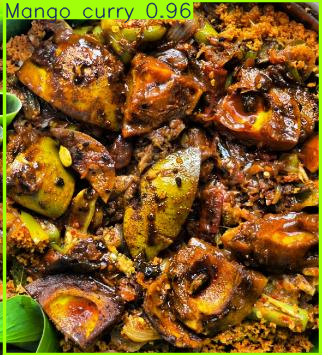

In [10]:
import random
import os

# Pick a random image from your validation set
valid_images_dir = os.path.join(dataset_path, "valid/images")
random_image = random.choice(os.listdir(valid_images_dir))
example_image = os.path.join(valid_images_dir, random_image)

print("Testing on:", random_image)
results = model.predict(example_image)
results[0].show()


Upload new meal plate images (you can select multiple):


Saving cake1.PNG to cake1.PNG
Saving Capture.PNG to Capture.PNG
Saving egg.PNG to egg.PNG
Saving egg3.jpg to egg3.jpg
Saving kol2.PNG to kol2.PNG
Saving man18.PNG to man18.PNG
Saving okra test2.PNG to okra test2.PNG
Saving papdam test.PNG to papdam test.PNG
Saving polos test2.jpg to polos test2.jpg
Saving Untitleddesign_13.webp to Untitleddesign_13.webp
10 image(s) uploaded for testing.

--- Testing: new_food_images/cake1.PNG ---

image 1/1 /content/new_food_images/cake1.PNG: 640x512 1 Papadam, 1 Sweets, 12.9ms
Speed: 1.8ms preprocess, 12.9ms inference, 1.2ms postprocess per image at shape (1, 3, 640, 512)

image 1/1 /content/new_food_images/cake1.PNG: 640x512 1 Papadam, 1 Sweets, 12.2ms
Speed: 1.6ms preprocess, 12.2ms inference, 1.1ms postprocess per image at shape (1, 3, 640, 512)


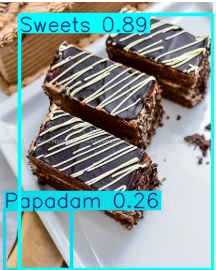

Detected foods:
  - Sweets, Confidence: 0.89
  - Papadam, Confidence: 0.26

--- Testing: new_food_images/Capture.PNG ---

image 1/1 /content/new_food_images/Capture.PNG: 608x640 (no detections), 51.1ms
Speed: 3.3ms preprocess, 51.1ms inference, 0.6ms postprocess per image at shape (1, 3, 608, 640)

image 1/1 /content/new_food_images/Capture.PNG: 608x640 (no detections), 16.0ms
Speed: 2.2ms preprocess, 16.0ms inference, 0.5ms postprocess per image at shape (1, 3, 608, 640)


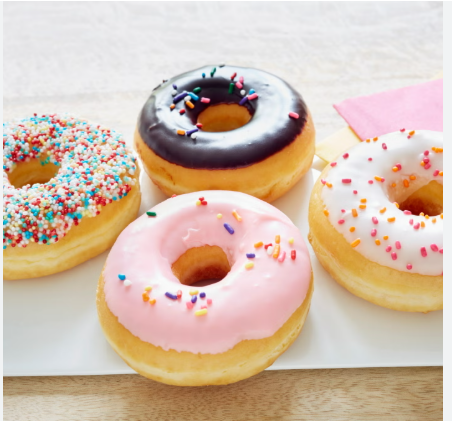

Detected foods:

--- Testing: new_food_images/egg.PNG ---

image 1/1 /content/new_food_images/egg.PNG: 640x608 2 Egg currys, 16.9ms
Speed: 4.6ms preprocess, 16.9ms inference, 1.4ms postprocess per image at shape (1, 3, 640, 608)

image 1/1 /content/new_food_images/egg.PNG: 640x608 2 Egg currys, 16.0ms
Speed: 3.0ms preprocess, 16.0ms inference, 1.6ms postprocess per image at shape (1, 3, 640, 608)


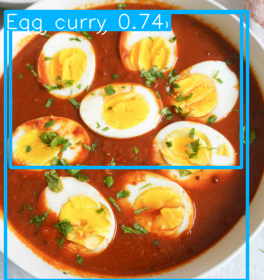

Detected foods:
  - Egg curry, Confidence: 0.74
  - Egg curry, Confidence: 0.55

--- Testing: new_food_images/egg3.jpg ---

image 1/1 /content/new_food_images/egg3.jpg: 576x640 (no detections), 68.1ms
Speed: 3.2ms preprocess, 68.1ms inference, 0.6ms postprocess per image at shape (1, 3, 576, 640)

image 1/1 /content/new_food_images/egg3.jpg: 576x640 (no detections), 15.8ms
Speed: 3.2ms preprocess, 15.8ms inference, 0.7ms postprocess per image at shape (1, 3, 576, 640)


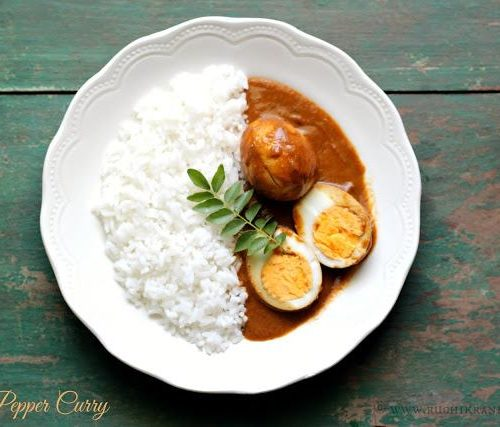

Detected foods:

--- Testing: new_food_images/kol2.PNG ---

image 1/1 /content/new_food_images/kol2.PNG: 640x512 (no detections), 13.3ms
Speed: 2.6ms preprocess, 13.3ms inference, 0.7ms postprocess per image at shape (1, 3, 640, 512)

image 1/1 /content/new_food_images/kol2.PNG: 640x512 (no detections), 12.2ms
Speed: 2.6ms preprocess, 12.2ms inference, 0.7ms postprocess per image at shape (1, 3, 640, 512)


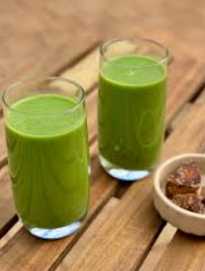

Detected foods:

--- Testing: new_food_images/man18.PNG ---

image 1/1 /content/new_food_images/man18.PNG: 640x544 1 Carrot, 67.1ms
Speed: 2.8ms preprocess, 67.1ms inference, 1.7ms postprocess per image at shape (1, 3, 640, 544)

image 1/1 /content/new_food_images/man18.PNG: 640x544 1 Carrot, 15.9ms
Speed: 2.9ms preprocess, 15.9ms inference, 1.6ms postprocess per image at shape (1, 3, 640, 544)


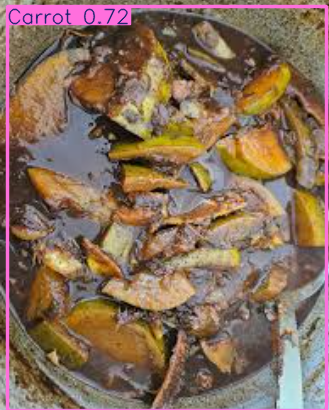

Detected foods:
  - Carrot, Confidence: 0.72

--- Testing: new_food_images/okra test2.PNG ---

image 1/1 /content/new_food_images/okra test2.PNG: 544x640 1 Okra curry, 16.8ms
Speed: 2.7ms preprocess, 16.8ms inference, 1.5ms postprocess per image at shape (1, 3, 544, 640)

image 1/1 /content/new_food_images/okra test2.PNG: 544x640 1 Okra curry, 15.8ms
Speed: 2.8ms preprocess, 15.8ms inference, 1.5ms postprocess per image at shape (1, 3, 544, 640)


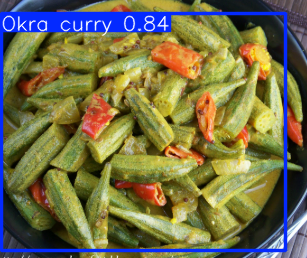

Detected foods:
  - Okra curry, Confidence: 0.84

--- Testing: new_food_images/papdam test.PNG ---

image 1/1 /content/new_food_images/papdam test.PNG: 608x640 (no detections), 17.1ms
Speed: 3.2ms preprocess, 17.1ms inference, 0.8ms postprocess per image at shape (1, 3, 608, 640)

image 1/1 /content/new_food_images/papdam test.PNG: 608x640 (no detections), 18.1ms
Speed: 4.2ms preprocess, 18.1ms inference, 0.9ms postprocess per image at shape (1, 3, 608, 640)


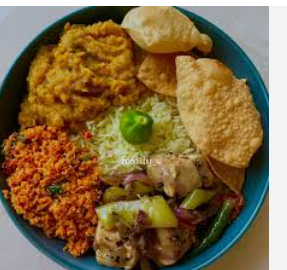

Detected foods:

--- Testing: new_food_images/polos test2.jpg ---

image 1/1 /content/new_food_images/polos test2.jpg: 384x640 1 Gotukola Mallum, 11.8ms
Speed: 4.9ms preprocess, 11.8ms inference, 1.5ms postprocess per image at shape (1, 3, 384, 640)

image 1/1 /content/new_food_images/polos test2.jpg: 384x640 1 Gotukola Mallum, 10.7ms
Speed: 2.7ms preprocess, 10.7ms inference, 1.7ms postprocess per image at shape (1, 3, 384, 640)


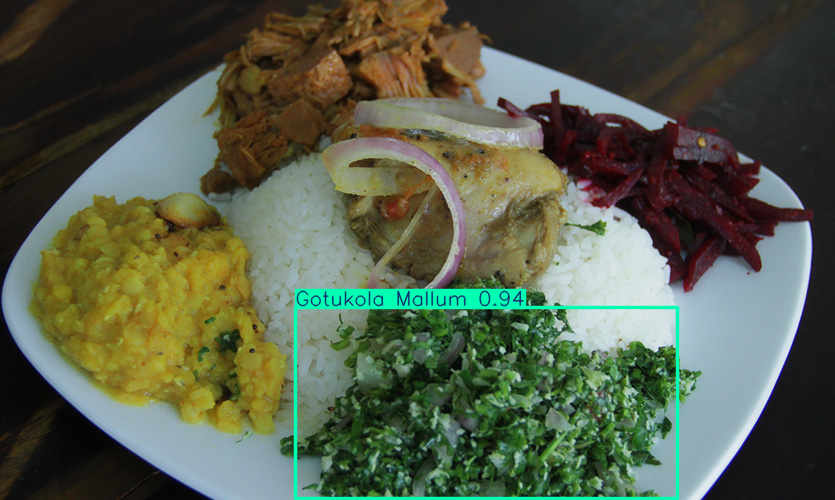

Detected foods:
  - Gotukola Mallum, Confidence: 0.94

--- Testing: new_food_images/Untitleddesign_13.webp ---

image 1/1 /content/new_food_images/Untitleddesign_13.webp: 640x640 1 Baked Filled, 17.4ms
Speed: 4.8ms preprocess, 17.4ms inference, 1.7ms postprocess per image at shape (1, 3, 640, 640)

image 1/1 /content/new_food_images/Untitleddesign_13.webp: 640x640 1 Baked Filled, 16.3ms
Speed: 4.6ms preprocess, 16.3ms inference, 1.8ms postprocess per image at shape (1, 3, 640, 640)


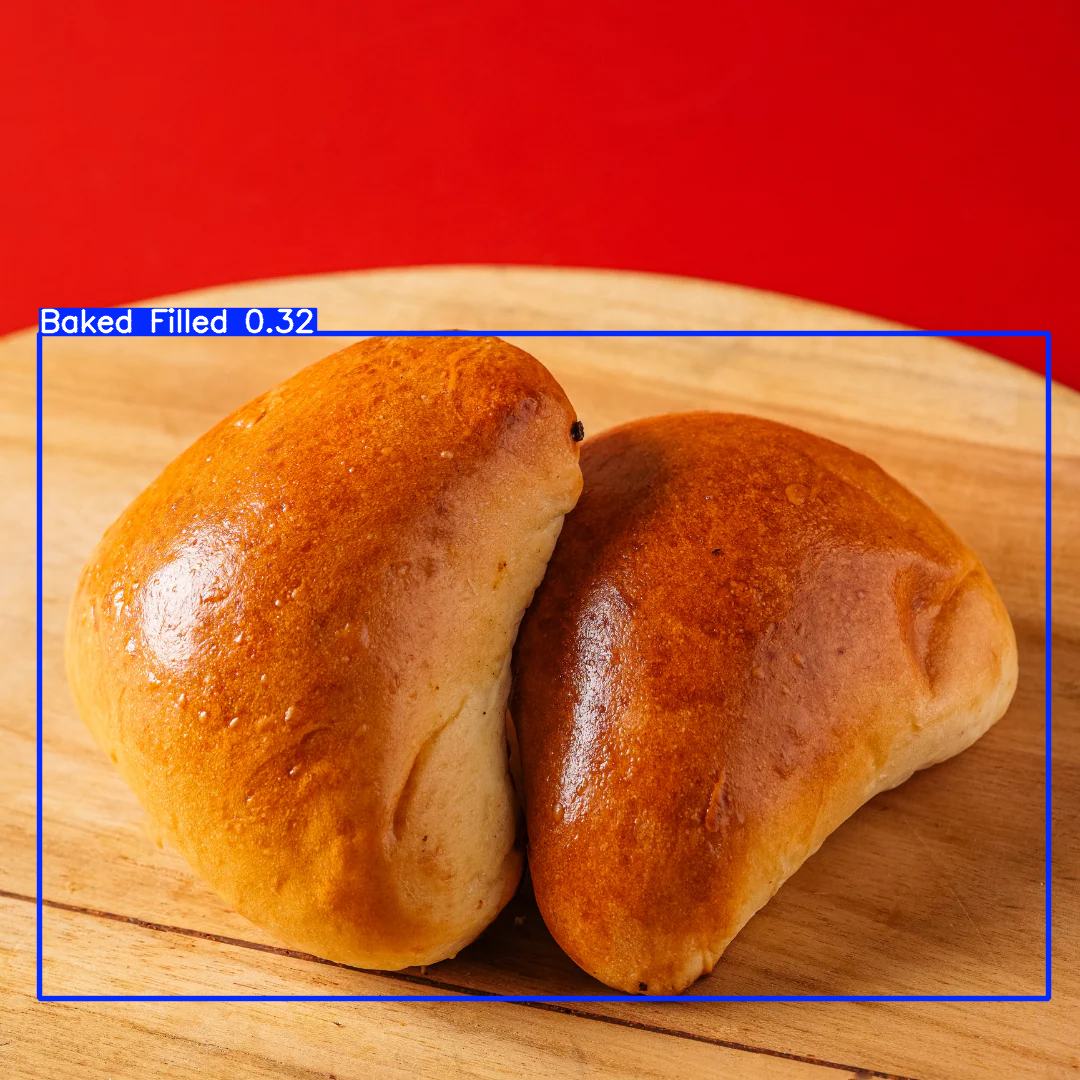

Detected foods:
  - Baked Filled, Confidence: 0.32


In [11]:
# ==========================
# Cell 3: Test on new/unseen images
# ==========================

from ultralytics import YOLO
from google.colab import files
import os

# 1️⃣ Load your trained YOLOv8 model
model = YOLO("/content/runs/detect/meal_plate_test/quick_train/weights/best.pt")

# 2️⃣ Upload one or more new images (simulate user uploads)
print("Upload new meal plate images (you can select multiple):")
uploaded = files.upload()  # user selects image files

# 3️⃣ Create a folder to save uploaded images
os.makedirs("new_food_images", exist_ok=True)

# Save uploaded images
uploaded_files = []
for filename in uploaded.keys():
    path = os.path.join("new_food_images", filename)
    uploaded_files.append(path)
    with open(path, "wb") as f:
        f.write(uploaded[filename])
print(f"{len(uploaded_files)} image(s) uploaded for testing.")

# 4️⃣ Run predictions on each uploaded image
for img_path in uploaded_files:
    print("\n--- Testing:", img_path, "---")
    results = model.predict(img_path)  # Run YOLO detection

    # Show the image with bounding boxes
    results = model.predict(img_path)  # Run YOLO detection

    # Show the image with bounding boxes
    results[0].show()

    # Print detected foods with confidence scores
    print("Detected foods:")
    for box in results[0].boxes:
        class_id = int(box.cls[0])
        confidence = float(box.conf[0])
        class_name = model.names[class_id]
        print(f"  - {class_name}, Confidence: {confidence:.2f}")
